In [1]:
import os
import pandas as pd
import pyranges as pr
import numpy as np
import seaborn as sns

from scipy.stats import spearmanr
from scipy.stats import pearsonr

import itertools

from scipy import stats

import random

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rc

# set style
plt.style.use('seaborn-v0_8-paper')

# set sizes
SMALL_SIZE = 5
MEDIUM_SIZE = 6
BIGGER_SIZE = 7
LARGE_SIZE = 12

def set_plotting():
    rc('font', size=MEDIUM_SIZE)          # controls default text sizes
    rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
    rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
    rc('xtick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
    rc('ytick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
    rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
    rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
    
def set_viewing():
    rc('font', size=LARGE_SIZE)          # controls default text sizes
    rc('axes', titlesize=LARGE_SIZE)     # fontsize of the axes title
    rc('axes', labelsize=LARGE_SIZE)    # fontsize of the x and y labels
    rc('xtick', labelsize=LARGE_SIZE)    # fontsize of the tick labels
    rc('ytick', labelsize=LARGE_SIZE)    # fontsize of the tick labels
    rc('legend', fontsize=LARGE_SIZE)    # legend fontsize
    rc('figure', titlesize=LARGE_SIZE)  # fontsize of the figure title

set_plotting()

# set font
rc('font', **{'family':'serif','serif':['Arial']})
rc('svg', **{'fonttype':'none'})

# one more change to axes and tick widths
rc('axes', **{'linewidth': 0.5, 'labelpad': 2.5})

rc('xtick', **{'major.width': 0.5, 'minor.width': 0.5, 'major.pad': 2.5})
rc('ytick', **{'major.width': 0.5, 'minor.width': 0.5, 'major.pad': 2.5})

In [3]:
def add_annotations_to_boxplot(ax, df, which_annotations, annotations, order, hue_order, offset=0, fontsize=12):
    """
    Add statistical significance annotations to a seaborn boxplot.
    
    Parameters:
    -----------
    ax : matplotlib axis
        The axis containing the boxplot
    df : pandas DataFrame
        The dataframe used to create the plot
    which_annotations : list of lists
        List of [x_label, hue_label] pairs to annotate
    annotations : list
        List of annotation strings (e.g., '***', 'ns', 'p<0.05')
    order : list
        Order of x-axis categories
    hue_order : list
        Order of hue categories
    offset : float, default=0
        Vertical offset for annotations from the top of boxes
    fontsize : int, default=12
        Font size for annotation text
    """
    from matplotlib.lines import Line2D
    
    # Get all lines from the plot (includes whiskers, medians, and box edges)
    lines = [child for child in ax.get_children() if isinstance(child, Line2D)]
    
    # Group lines by their x-position to identify each box
    # We'll look for the top horizontal line of each box (75th percentile)
    box_data = []
    
    # Collect all horizontal lines (these are the box quartile lines)
    horizontal_lines = []
    for line in lines:
        xdata = line.get_xdata()
        ydata = line.get_ydata()
        
        # Horizontal lines have the same y-value at both endpoints
        if len(xdata) == 2 and len(ydata) == 2 and abs(ydata[0] - ydata[1]) < 1e-10:
            x_center = (xdata[0] + xdata[1]) / 2
            y_pos = ydata[0]
            horizontal_lines.append([x_center, y_pos])
    
    # Sort by x position, then by y position (descending)
    horizontal_lines = sorted(horizontal_lines, key=lambda x: (x[0], -x[1]))
    
    # For each unique x position, take the highest line (75th percentile)
    seen_x = set()
    for line_data in horizontal_lines:
        x_pos = round(line_data[0], 6)  # Round to avoid floating point issues
        if x_pos not in seen_x:
            box_data.append(line_data)
            seen_x.add(x_pos)
    
    # Sort final box_data by x position
    box_data = sorted(box_data, key=lambda x: x[0])

    print(box_data)
    
    i_annotation = 0
    i_combination = 0
    
    # Iterate through all combinations of order and hue_order
    for i, label in enumerate(order):
        for j, hue_label in enumerate(hue_order):
            
            x = box_data[i_combination][0]
            y = box_data[i_combination][1]
            
            # Check if this combination should be annotated
            if [label, hue_label] in which_annotations:
                
                if y < 0:
                    va = 'top'
                    ax.text(
                        x,
                        y + offset,
                        annotations[i_annotation],
                        ha='center',
                        va=va,
                        fontsize=fontsize
                    )
                else:
                    va = 'bottom'
                    ax.text(
                        x,
                        y + offset,
                        annotations[i_annotation],
                        ha='center',
                        va=va,
                        fontsize=fontsize
                    )
                
                i_annotation += 1
            
            i_combination += 1

In [4]:
def check_neg_inf(df):
    # Function to safely check for -inf in a column
    def has_neg_inf(column):
        if pd.api.types.is_numeric_dtype(column):
            return np.isinf(column) & (column < 0)
        else:
            return pd.Series([False] * len(column))

    # Apply the function to each column
    neg_inf_mask = df.apply(has_neg_inf)
    
    # Get columns with any -inf values
    columns_with_neg_inf = neg_inf_mask.any()[neg_inf_mask.any()].index.tolist()
    
    return columns_with_neg_inf

In [8]:
# 1. intersect genes with UMRs
# 2. for each gene, we find the distance from TSS to border of the overlapping UMR, keeping upstream/downstream in mind
# 3. we also want to find if the umr is actually at the TSS
# 4. TSS should be center

path_gene_expr = '../sc_rna_seq/bed/bed_promoter_2000_8000/stats_cutoffs.bed'

path_umr_wt = 'SRR8611939.umr.merged.bed'
path_umr_tko = 'SRR8611941.umr.merged.bed'
path_umr_dko = 'SRR8700960.umr.merged.bed'


In [9]:
df_gene_expr = pd.read_csv(path_gene_expr, sep='\t')

rename_map = {
    '#chrom': 'Chromosome',
    'start': 'Start',
    'stop': 'End',
    'strand': 'Strand',
    'gene': 'Gene',
    'log_mean_wt': 'Log2(Mean) WT',
    'log_mean_dko': 'Log2(Mean) DKO',
    'log_mean_tko': 'Log2(Mean) TKO',
    'zero_ratio_diff_dko': 'Zero Ratio Diff DKO/WT',
    'zero_ratio_diff_tko': 'Zero Ratio Diff TKO/WT',
    'MeanLog2FC_tko': 'LFC Mean TKO/WT',
    'MeanLog2FC_dko': 'LFC Mean DKO/WT',
    'DispLog2FC_tko': 'LFC Disp TKO/WT',
    'DispLog2FC_dko': 'LFC Disp DKO/WT',
    'log_dispersion_nonzero_diff_tko': 'LFC NZDisp TKO/WT',
    'log_dispersion_nonzero_diff_dko': 'LFC NZDisp DKO/WT',
    'mean_diff_tko': 'Linear Diff Mean TKO/WT',
    'mean_diff_dko': 'Linear Diff Mean DKO/WT',
    'residual_diff_tko': 'Residual Diff TKO/WT',
    'residual_diff_dko': 'Residual Diff DKO/WT',
}

df_gene_expr['residual_diff_tko'] = df_gene_expr['residual_diff_tko'] * 100
df_gene_expr['residual_diff_dko'] = df_gene_expr['residual_diff_dko'] * 100

df_gene_expr.rename(columns=rename_map, inplace=True)

# make start and end for TSS, which is just the midpoint
# each entry is some equidistant point around the TSS
df_gene_expr['TSS'] = (df_gene_expr['Start'] + df_gene_expr['End'])/2
df_gene_expr['Start'] = df_gene_expr['TSS'] - 1
df_gene_expr['End'] = df_gene_expr['TSS'] + 1
df_gene_expr['log_length'] = np.log10(df_gene_expr['length'])
df_gene_expr['length'] = df_gene_expr['length'] / 1000

print('number of genes:', len(df_gene_expr.index))

number of genes: 15870


In [19]:
def set_lengths(df, suffix):

    # When no UMR aligns with gene, we get a -1 in End_UMR/Start_UMR
    # Fine for canyon length, this just results in 0,
    # which gets set to 1, basically means no canyon
    
    # For downstream/upstream

    df[f'UMR Length {suffix}'] = np.where(
        (df[f'End_UMR_{suffix}'] == -1) | (df[f'Start_UMR_{suffix}'] == -1),
        1,
        df[f'End_UMR_{suffix}'] - df[f'Start_UMR_{suffix}']
    )
    df[f'log10(UMR Length {suffix})'] = np.log10(df[f'UMR Length {suffix}'])
    
    df[f'Downstream UMR Border {suffix}'] = np.where(
        (df[f'End_UMR_{suffix}'] == -1) | (df[f'Start_UMR_{suffix}'] == -1),
        1,
        np.where(
            df['Strand'] == '+',
            abs(df[f'End_UMR_{suffix}'] - df['TSS']), 
            abs(df[f'Start_UMR_{suffix}'] - df['TSS'])
        )
    )
    # cap for when umr and gene overlap borders are same basepair
    df[f'Downstream UMR Border {suffix}'] = df[f'Downstream UMR Border {suffix}'].clip(lower=1)
    df[f'log10(Downstream UMR Border {suffix})'] = np.log10(df[f'Downstream UMR Border {suffix}'])
    
    df[f'Upstream UMR Border {suffix}'] = np.where(
        (df[f'End_UMR_{suffix}'] == -1) | (df[f'Start_UMR_{suffix}'] == -1),
        1,
        np.where(
            df['Strand'] == '+', 
            abs(df[f'Start_UMR_{suffix}'] - df['TSS']), 
            abs(df[f'End_UMR_{suffix}'] - df['TSS'])
        )
    )
    df[f'Upstream UMR Border {suffix}'] = df[f'Upstream UMR Border {suffix}'].clip(lower=1)
    df[f'log10(Upstream UMR Border {suffix})'] = np.log10(df[f'Upstream UMR Border {suffix}'])

def set_length_changes(df_intersection, suffix1, suffix2):
    
    df_intersection[f'Δ UMR Length {suffix2}/{suffix1}'] = df_intersection[f'UMR Length {suffix2}'] - df_intersection[f'UMR Length {suffix1}']
    df_intersection[f'Δ Upstream UMR Border {suffix2}/{suffix1}'] = df_intersection[f'Upstream UMR Border {suffix2}'] - df_intersection[f'Upstream UMR Border {suffix1}']
    df_intersection[f'Δ Downstream UMR Border {suffix2}/{suffix1}'] = df_intersection[f'Downstream UMR Border {suffix2}'] - df_intersection[f'Downstream UMR Border {suffix1}']

def set_canyon_class(df_intersection, parameter, suffix, cutoffs):
    
    # Sort cutoffs in descending order to ensure proper ordering
    cutoffs = sorted(cutoffs, reverse=True)
    
    col_name = f'{parameter} {suffix}'
    conditions = []
    choices = []
    
    # Create conditions for values >= each cutoff (starting from highest)
    for i, cutoff in enumerate(cutoffs):
        if i == 0:
            # First condition: greater than or equal to highest cutoff
            conditions.append(df_intersection[col_name] >= cutoff)
            if cutoff >= 1000:
                choices.append(f'>{cutoff//1000}kbp')
            else:
                choices.append(f'>{cutoff}bp')
        else:
            # Middle conditions: between this cutoff and the previous one
            prev_cutoff = cutoffs[i-1]
            conditions.append(df_intersection[col_name] >= cutoff)
            if cutoff >= 1000 and prev_cutoff >= 1000:
                choices.append(f'{cutoff//1000}-{prev_cutoff//1000}kbp')
            elif cutoff >= 1000:
                choices.append(f'{cutoff//1000}k-{prev_cutoff}bp')
            else:
                choices.append(f'{cutoff}-{prev_cutoff}bp')
    
    # Condition for values below smallest cutoff but greater than 1
    smallest_cutoff = cutoffs[-1]
    conditions.append(
        (df_intersection[col_name] < smallest_cutoff) & (df_intersection[col_name] > 1)
    )
    if smallest_cutoff >= 1000:
        choices.append(f'0-{smallest_cutoff//1000}kbp')
    else:
        choices.append(f'0-{smallest_cutoff}bp')
    
    # Hard-coded condition for 'No UMR' (value == 1)
    conditions.append(df_intersection[col_name] == 1)
    choices.append('No UMR')
    
    # Apply classification
    df_intersection[f'{parameter} {suffix} Class'] = np.select(conditions, choices, default='Unclassified')

    return choices

def set_canyon_change_class(df_intersection, parameter, suffix1, suffix2, high_change_limit):
    
    conditions = [
        (df_intersection[f'{parameter} {suffix1}'] == 0) & (df_intersection[f'{parameter} {suffix2}'] == 0),
        (df_intersection[f'{parameter} {suffix1}'] > 0) & (df_intersection[f'{parameter} {suffix2}'] == 0),
        (df_intersection[f'{parameter} {suffix1}'] == 0) & (df_intersection[f'{parameter} {suffix2}'] > 0),
        (np.abs(df_intersection[f'Δ {parameter} {suffix2}/{suffix1}']) >= high_change_limit),
        (np.abs(df_intersection[f'Δ {parameter} {suffix2}/{suffix1}']) >= 1000),
        (np.abs(df_intersection[f'Δ {parameter} {suffix2}/{suffix1}']) < 1000)
    ]
    choices = ['No UMR in Either', 'Complete UMR Loss', 'Complete UMR Gain', f'>{int(high_change_limit/1000)}kbp', '>1kbp', '<1kbp']
    df_intersection[f'{parameter} Change {suffix2}/{suffix1} Class'] = np.select(conditions, choices, default='Unclassified')
    

In [28]:
high_limit = 5000
high_change_limit_tko = 10000
high_change_limit_dko = 3000
high_change_limit_updown = 3000

names_umr = ['Chromosome', 'Start', 'End', 'Name', 'Score', 'Strand', 'thickStart', 'thickEnd', 'itemRgb']
df_umr_wt = pd.read_csv(path_umr_wt, sep='\t', header=None, skiprows=1, names=names_umr)
df_umr_tko = pd.read_csv(path_umr_tko, sep='\t', header=None, skiprows=1, names=names_umr)
df_umr_dko = pd.read_csv(path_umr_dko, sep='\t', header=None, skiprows=1, names=names_umr)

pr_gene = pr.PyRanges(df_gene_expr)
pr_umr_wt = pr.PyRanges(df_umr_wt)
pr_umr_tko = pr.PyRanges(df_umr_tko)
pr_umr_dko = pr.PyRanges(df_umr_dko)

# We do left intersection, and thus length_UMR ends up being zero if no UMR is present
intersection = pr_gene.join(pr_umr_wt, suffix="_UMR_WT", how='left')
intersection = intersection.join(pr_umr_tko, suffix="_UMR_TKO", how='left')
intersection = intersection.join(pr_umr_dko, suffix="_UMR_DKO", how='left')

df_intersection = intersection.df

print('initial intersection num genes:', len(df_intersection.index))

set_lengths(df_intersection, 'WT')
set_lengths(df_intersection, 'TKO')
set_lengths(df_intersection, 'DKO')

set_length_changes(df_intersection, 'WT', 'TKO')
set_length_changes(df_intersection, 'WT', 'DKO')

# Check to see if there are any weird values
columns_with_neg_inf = check_neg_inf(df_intersection)
print('Columns with -inf:', columns_with_neg_inf)

cutoffs_canyon = [3000, 6000, 9000]
choices_canyon = set_canyon_class(df_intersection, 'UMR Length', 'WT', cutoffs_canyon)
set_canyon_class(df_intersection, 'UMR Length', 'TKO', cutoffs_canyon)
set_canyon_class(df_intersection, 'UMR Length', 'DKO', cutoffs_canyon)

cutoffs_sides = [2000, 4000]
#cutoffs_sides = [3000, 6000, 9000]
choices_sides = set_canyon_class(df_intersection, 'Upstream UMR Border', 'WT', cutoffs_sides)
set_canyon_class(df_intersection, 'Downstream UMR Border', 'WT', cutoffs_sides)
set_canyon_class(df_intersection, 'Upstream UMR Border', 'TKO', cutoffs_sides)
set_canyon_class(df_intersection, 'Downstream UMR Border', 'TKO', cutoffs_sides)
set_canyon_class(df_intersection, 'Upstream UMR Border', 'DKO', cutoffs_sides)
set_canyon_class(df_intersection, 'Downstream UMR Border', 'DKO', cutoffs_sides)

set_canyon_change_class(df_intersection, 'UMR Length', 'WT', 'TKO', high_change_limit_tko)
set_canyon_change_class(df_intersection, 'UMR Length', 'WT', 'DKO', high_change_limit_dko)
set_canyon_change_class(df_intersection, 'Upstream UMR Border', 'WT', 'TKO', high_change_limit_updown)
set_canyon_change_class(df_intersection, 'Upstream UMR Border', 'WT', 'DKO', high_change_limit_updown)
set_canyon_change_class(df_intersection, 'Downstream UMR Border', 'WT', 'TKO', high_change_limit_updown)
set_canyon_change_class(df_intersection, 'Downstream UMR Border', 'WT', 'DKO', high_change_limit_updown)

print('final num genes:', len(df_intersection.index))

# this was done for linear regression or other ML approach, didnt work but can revisit
# also using for ECDF generation
value_vars = [column for column in df_intersection.columns if 'UMR Length' in column and 'Class' not in column]
df_long = pd.melt(df_intersection, 
                  id_vars=['Gene', 'Promoter Class'],
                  value_vars=value_vars,
                  var_name='parameter',
                  value_name='value')

df_long['parameter_combined'] = df_long['Promoter Class'] + ' ' + df_long['parameter']
print(df_long)

df_intersection['Combined Downstream UMR Border TKO Class'] = 'WT:' + df_intersection['Downstream UMR Border TKO Class'] + ' TKO:' + df_intersection['Downstream UMR Border WT Class']


initial intersection num genes: 15870
Columns with -inf: []
final num genes: 15870
            Gene   Promoter Class            parameter   value  \
0           GUK1         H3K27me3        UMR Length WT  1193.0   
1         LRRC71         Bivalent        UMR Length WT   898.0   
2       SLC25A44          H3K4me3        UMR Length WT   908.0   
3        IL12RB2         Bivalent        UMR Length WT  1046.0   
4          HDAC1          H3K4me3        UMR Length WT   885.0   
...          ...              ...                  ...     ...   
126955     KDM5D  All Other Genes  Δ UMR Length DKO/WT   231.0   
126956       SRY  All Other Genes  Δ UMR Length DKO/WT  1492.0   
126957    TTTY14  All Other Genes  Δ UMR Length DKO/WT  1469.0   
126958    GYG2P1  All Other Genes  Δ UMR Length DKO/WT     0.0   
126959       UTY  All Other Genes  Δ UMR Length DKO/WT     0.0   

                         parameter_combined  
0                    H3K27me3 UMR Length WT  
1                    Bivalent UM

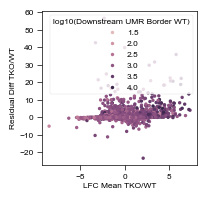

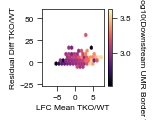

In [29]:
df_bivalent = df_intersection.loc[
    (df_intersection['Promoter Class'] == 'Bivalent') &
    (df_intersection['log10(Downstream UMR Border WT)'] > 0)
]

fig, ax = plt.subplots(figsize=(2,2))

x='LFC Mean TKO/WT'
y='Residual Diff TKO/WT'
c='log10(Downstream UMR Border WT)'

sns.scatterplot(
    data=df_bivalent,
    x=x,
    y=y,
    hue='log10(Downstream UMR Border WT)',
    s=6,
    linewidth=0,
    ax=ax
)
plt.show()

fig, ax = plt.subplots(figsize=(1,1))
hexbin = ax.hexbin(
    df_bivalent[x], 
    df_bivalent[y], 
    C=df_bivalent[c],  # Values to aggregate
    gridsize=20,  # Number of hexagons
    reduce_C_function=np.mean,  # Function to aggregate (mean by default)
    cmap='magma',  # Color map
    mincnt=2  # Minimum number of points per bin to display
)

# Add colorbar
cbar = plt.colorbar(hexbin, ax=ax)
cbar.set_label('Average log10(Downstream UMR Border WT)', rotation=270, labelpad=10)

# Labels
ax.set_xlabel(x)
ax.set_ylabel(y)

#plt.ylim([-10,20])
#plt.xlim([-10,20])

fig.savefig('figures/fcmean_residual_hexbin.svg')


Mean Residual Diff TKO/WT: 0.7693669488512915


/tmp/ipykernel_2301514/2518954759.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filt.dropna(inplace=True)


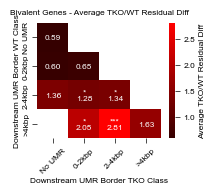

/tmp/ipykernel_2301514/2518954759.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filt.dropna(inplace=True)


Mean Residual Diff DKO/WT: -0.0949751127712643


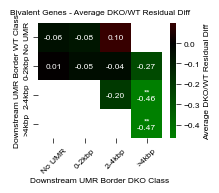

/tmp/ipykernel_2301514/2518954759.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filt.dropna(inplace=True)


Mean Zero Ratio Diff TKO/WT: -0.0028576653840957584


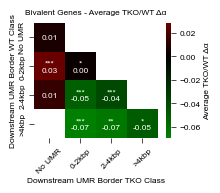

/tmp/ipykernel_2301514/2518954759.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filt.dropna(inplace=True)


Mean LFC Mean TKO/WT: -0.05223406900839291


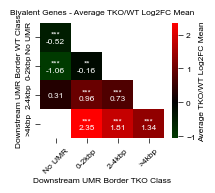

/tmp/ipykernel_2301514/2518954759.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filt.dropna(inplace=True)


Mean LFC Mean DKO/WT: -0.1913425361155698


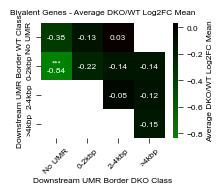

/tmp/ipykernel_2301514/2518954759.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filt.dropna(inplace=True)


Mean Zero Ratio Diff DKO/WT: 0.0019263947690766894


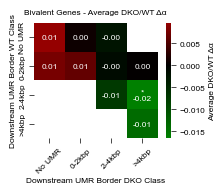

In [30]:
# heatmap plan:
# x: Canyon Length WT Class Bin
# y: Canyon Length TKO Class Bin
# hue: Zero Ratio Diff TKO/WT

# assign bins for methylation canyon sizes
from matplotlib.colors import LinearSegmentedColormap
from statsmodels.stats.multitest import multipletests

color_min    = "green"
color_center = "black"
color_max    = "red"
cmap = LinearSegmentedColormap.from_list(
    "cmap_name",
    [color_min, color_center, color_max]
)

def str_to_filename(string):
    string = string.replace('\\', '_').replace(' ', '_').lower()
    return string

def plot_heatmap_relational(df_intersection, param, canyon_parameter, suffix1, suffix2, choices):
    
    min_gene_count = 5

    if 'Zero' in param:
        param_title = 'Δα'
    else:
        param_title = param.replace('LFC', 'Log2FC')

    filename = '_'.join([str_to_filename(param), str_to_filename(canyon_parameter)])

    df_filt = df_intersection[['Promoter Class', f'{canyon_parameter} {suffix1} Class', f'{canyon_parameter} {suffix2} Class', f'{param} {suffix2}/{suffix1}', 'Log2(Mean) WT']]
    df_filt.dropna(inplace=True)
    
    df_grouped_counts = df_filt.groupby(by=['Promoter Class', f'{canyon_parameter} {suffix1} Class', f'{canyon_parameter} {suffix2} Class']).count()
    df_grouped = df_filt.groupby(by=['Promoter Class', f'{canyon_parameter} {suffix1} Class', f'{canyon_parameter} {suffix2} Class']).mean(numeric_only=True)
    
    mask = df_grouped_counts < min_gene_count
    df_grouped = df_grouped.mask(mask, other=np.nan)
    df_grouped.reset_index(inplace=True)
    
    promoter_classes = ['Bivalent']
    values = f'{param} {suffix2}/{suffix1}'
    
    for promoter in promoter_classes:

        df_all_mean = df_intersection.loc[df_intersection['Promoter Class'] == promoter]
        
        # Create wide df
        df_promoter = df_grouped.loc[df_grouped['Promoter Class'] == promoter]
        df_wide = df_promoter.pivot(index=f'{canyon_parameter} {suffix1} Class', columns=f'{canyon_parameter} {suffix2} Class', values=values).reset_index()
        df_wide.set_index(f'{canyon_parameter} {suffix1} Class', inplace=True)
        df_wide = df_wide.reindex(columns = list(reversed(choices)))
        df_wide = df_wide.reindex(index = list(reversed(choices)))
        
        # Compute significance
        annot = compute_significance_annotations(
            df_filt[df_filt['Promoter Class'] == promoter],
            df_wide,
            f'{canyon_parameter} {suffix1} Class',
            f'{canyon_parameter} {suffix2} Class',
            values
        )
    
        fig, ax = plt.subplots(figsize=(2,1.5))
        #fig, ax = plt.subplots(figsize=(1.5,1))
        sns.heatmap(df_wide, cmap=cmap, center=0, ax=ax, annot=annot, fmt='', cbar_kws={'label': f'Average {suffix2}/{suffix1} {param_title}'})
        ax.set_title(f'{promoter} Genes - Average {suffix2}/{suffix1} {param_title}')
        plt.xticks(rotation=45) 
        fig.savefig(f'figures/heatmap_{suffix2}_{suffix1}_{promoter}_{filename}.svg')
        plt.show()
        plt.close()

def compute_significance_annotations(df_filtered, df_wide, wt_col, ko_col, value_col):
    """
    Compute significance annotations for heatmap cells.
    Each cell is compared against all other values using t-test with BH correction.
    """
    # Get all values for this promoter class
    all_values = df_filtered[value_col].values
    
    # Initialize annotation matrix
    annot = df_wide.astype(str).copy()
    
    # Collect p-values for multiple testing correction
    p_values = []
    cell_info = []

    other_values = df_filtered[value_col].values
    print(f'Mean {value_col}:', np.mean(other_values))
    
    for row_idx, row_name in enumerate(df_wide.index):
        for col_idx, col_name in enumerate(df_wide.columns):
            cell_value = df_wide.iloc[row_idx, col_idx]
            
            if pd.isna(cell_value):
                annot.iloc[row_idx, col_idx] = ''
                continue
            
            # Get values for this specific cell
            cell_mask = (df_filtered[wt_col] == row_name) & (df_filtered[ko_col] == col_name)
            cell_values = df_filtered.loc[cell_mask, value_col].values
            
            if len(cell_values) < 3 or len(other_values) < 3:
                annot.iloc[row_idx, col_idx] = f'{cell_value:.2f}'
                continue
            
            # Perform t-test
            if np.mean(cell_values) > np.mean(other_values):
                t_stat, p_val = stats.ttest_ind(cell_values, other_values, alternative='greater')
            else:
                t_stat, p_val = stats.ttest_ind(cell_values, other_values, alternative='less')
                
            p_values.append(p_val)
            cell_info.append((row_idx, col_idx, cell_value))
    
    # Apply Benjamini-Hochberg correction
    if len(p_values) > 0:
        reject, pvals_corrected, _, _ = multipletests(p_values, method='fdr_bh')
        
        # Add significance stars
        for i, (row_idx, col_idx, cell_value) in enumerate(cell_info):
            p_adj = pvals_corrected[i]
            
            if p_adj < 0.001:
                stars = '***\n'
            elif p_adj < 0.01:
                stars = '**\n'
            elif p_adj < 0.05:
                stars = '*\n'
            else:
                stars = ''
            
            annot.iloc[row_idx, col_idx] = f'{stars}{cell_value:.2f}'
    
    return annot

plot_heatmap_relational(df_intersection, 'Residual Diff', 'Downstream UMR Border', 'WT', 'TKO', choices_sides)

plot_heatmap_relational(df_intersection, 'Residual Diff', 'Downstream UMR Border', 'WT', 'DKO', choices_sides)

plot_heatmap_relational(df_intersection, 'Zero Ratio Diff', 'Downstream UMR Border', 'WT', 'TKO', choices_sides)

plot_heatmap_relational(df_intersection, 'LFC Mean', 'Downstream UMR Border', 'WT', 'TKO', choices_sides)

plot_heatmap_relational(df_intersection, 'LFC Mean', 'Downstream UMR Border', 'WT', 'DKO', choices_sides)

plot_heatmap_relational(df_intersection, 'Zero Ratio Diff', 'Downstream UMR Border', 'WT', 'DKO', choices_sides)
    

Mean Expression of Large UMR in WT: -6.617608345222586
Mean Expression Change of Low Expression in WT: 1.0307936507936508
Mean Expression Change of Large UMR: 2.1887142857142856
Mean Expression Change of Sampled Genes: 0.4504455857142857
TtestResult(statistic=8.06180125874326, pvalue=7.635440047367255e-16, df=70068.0)


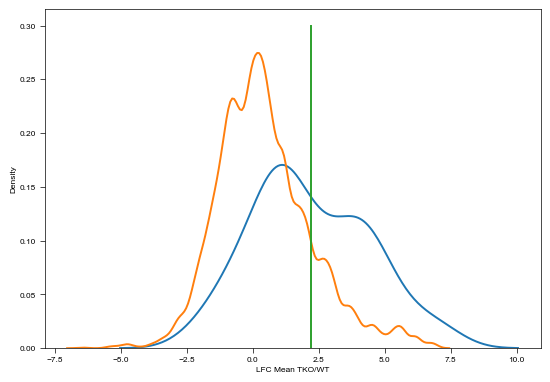

In [71]:
df_bivalent_test = df_bivalent.copy()

df_bivalent_test.replace([-np.inf], np.nan, inplace=True)
df_bivalent_test.dropna(subset=['Log2(Mean) WT', 'Log2(Mean) TKO'], inplace=True)

df_small_umr = df_bivalent_test.loc[df_bivalent_test['color_wt'] == 1]
df_large_umr = df_bivalent_test.loc[df_bivalent_test['color_wt'] == 4]

print('Mean Expression of Large UMR in WT:', np.mean(df_large_umr['Log2(Mean) WT']))

df_low_expr = df_bivalent.loc[df_bivalent['Log2(Mean) WT'] < np.mean(df_large_umr['Log2(Mean) WT'])]
print('Mean Expression Change of Low Expression in WT:', np.mean(df_low_expr['LFC Mean TKO/WT']))
print('Mean Expression Change of Large UMR:', np.mean(df_large_umr['LFC Mean TKO/WT']))

tolerance = 0.05
num_randomizations = 1000
mean_lfcs = []
mean_means = []

all_lfcs = []

for i in range(num_randomizations):
    similar_mean_lfc = []
    similar_mean_mean = []
    for record in df_large_umr.to_records('dict'):
        mean = record['Log2(Mean) WT']
        df_filt = df_small_umr.loc[(df_small_umr['Log2(Mean) WT'] > mean - tolerance) & (df_small_umr['Log2(Mean) WT'] < mean + tolerance)]
        if len(df_filt.index) > 0:
            random_i = random.randint(0, len(df_filt.index) - 1)
            similar_mean_lfc.append(list(df_filt['LFC Mean TKO/WT'])[random_i])
            similar_mean_mean.append(list(df_filt['Log2(Mean) WT'])[random_i])
            all_lfcs.append(list(df_filt['LFC Mean TKO/WT'])[random_i])

    mean_lfcs.append(np.mean(similar_mean_lfc))
    mean_means.append(np.mean(similar_mean_mean))

print('Mean Expression Change of Sampled Genes:', np.mean(mean_lfcs))

res = stats.ttest_ind(df_large_umr['LFC Mean TKO/WT'], all_lfcs)
print(res)

sns.kdeplot(data=df_large_umr, x='LFC Mean TKO/WT', label='Large WT Canyon Genes')

mean_lfc_large_umr = np.mean(df_large_umr['LFC Mean TKO/WT'])

sns.kdeplot(all_lfcs, label='Sampled Genes')
plt.plot([mean_lfc_large_umr, mean_lfc_large_umr], [0, 0.3])
plt.show()


Mean WT Expression: -3.608520049309547
Mean WT Expression of Large UMR in DKO: -3.286886849548812
Mean Expression Change of High Expression in WT: -0.13359757330637007
Mean Expression Change of Large Change UMR: -0.2975783132530121
Mean Expression Change of Sampled Genes: -0.1316751472392638


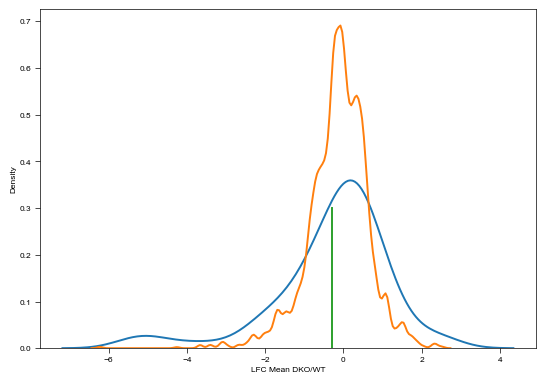

In [38]:
df_bivalent_test = df_bivalent.copy()

df_bivalent_test.replace([-np.inf], np.nan, inplace=True)
df_bivalent_test.dropna(subset=['Log2(Mean) WT', 'Log2(Mean) DKO'], inplace=True)

df_small_umr = df_bivalent_test.loc[df_bivalent_test['color_dko'] == 1]
df_large_umr = df_bivalent_test.loc[df_bivalent_test['color_dko'] == 4]

print('Mean WT Expression:', np.mean(df_bivalent['Log2(Mean) WT']))
print('Mean WT Expression of Large UMR in DKO:', np.mean(df_large_umr['Log2(Mean) WT']))

df_high_expr = df_bivalent.loc[df_bivalent['Log2(Mean) WT'] > np.mean(df_large_umr['Log2(Mean) WT'])]
print('Mean Expression Change of High Expression in WT:', np.mean(df_high_expr['LFC Mean DKO/WT']))
print('Mean Expression Change of Large Change UMR:', np.mean(df_large_umr['LFC Mean DKO/WT']))

tolerance = 0.05
num_randomizations = 1000
mean_lfcs = []
mean_means = []

all_lfcs = []

for i in range(num_randomizations):
    similar_mean_lfc = []
    similar_mean_mean = []
    for record in df_large_umr.to_records('dict'):
        mean = record['Log2(Mean) WT']
        df_filt = df_small_umr.loc[(df_small_umr['Log2(Mean) WT'] > mean - tolerance) & (df_small_umr['Log2(Mean) WT'] < mean + tolerance)]
        if len(df_filt.index) > 0:
            random_i = random.randint(0, len(df_filt.index) - 1)
            similar_mean_lfc.append(list(df_filt['LFC Mean DKO/WT'])[random_i])
            similar_mean_mean.append(list(df_filt['Log2(Mean) WT'])[random_i])
            all_lfcs.append(list(df_filt['LFC Mean DKO/WT'])[random_i])

    mean_lfcs.append(np.mean(similar_mean_lfc))
    mean_means.append(np.mean(similar_mean_mean))

print('Mean Expression Change of Sampled Genes:', np.mean(mean_lfcs))

res = stats.ttest_ind(df_large_umr['LFC Mean DKO/WT'], all_lfcs)
print(res)

sns.kdeplot(data=df_large_umr, x='LFC Mean DKO/WT', label='Large WT Canyon Genes')

mean_lfc_large_umr = np.mean(df_large_umr['LFC Mean DKO/WT'])

sns.kdeplot(all_lfcs, label='Sampled Genes')
plt.plot([mean_lfc_large_umr, mean_lfc_large_umr], [0, 0.3])
plt.show()


/tmp/ipykernel_302590/3769008218.py:45: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_group = df_long_filt.groupby(['Promoter Class', 'parameter']).mean()


                                             value
Promoter Class  parameter                         
All Other Genes UMR Length DKO         1196.989749
                UMR Length TKO          453.927752
                UMR Length WT           558.062973
                log10(UMR Length DKO)     3.207657
                log10(UMR Length TKO)     3.058310
                log10(UMR Length WT)      3.074717
                Δ UMR Length DKO/WT    1243.979282
                Δ UMR Length TKO/WT     162.914439
Bivalent        UMR Length DKO         4127.508787
                UMR Length TKO         1504.342999
                UMR Length WT          2222.668424
                log10(UMR Length DKO)     3.508634
                log10(UMR Length TKO)     3.146257
                log10(UMR Length WT)      3.267168
                Δ UMR Length DKO/WT    2033.046404
                Δ UMR Length TKO/WT     285.887218
H3K27me3        UMR Length DKO         2092.569757
                UMR Length TKO 

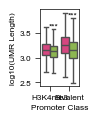

(('H3K4me3', 'log10(UMR Length WT)'), ('H3K4me3', 'log10(UMR Length DKO)')) 0.0
(('Bivalent', 'log10(UMR Length WT)'), ('Bivalent', 'log10(UMR Length DKO)')) 3.3743025597756046e-227
[[-0.2, 3.6180480967120925], [0.20000000000000007, 3.8793253007848074], [0.8, 3.9024924211586036], [1.2000000000000002, 4.166015456323775]]


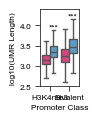

In [14]:
def get_annotations_long(df_long_filt, pairs):
    annotations = []
    which_annotations = []
    for pair in pairs:
    
        promoter_1 = pair[0][0]
        promoter_2 = pair[1][0]
    
        param_1 = pair[0][1]
        param_2 = pair[1][1]
    
        vals_1 = df_long_filt.loc[(df_long_filt['Promoter Class'] == promoter_1) & (df_long_filt['parameter'] == param_1)]['value']
        vals_2 = df_long_filt.loc[(df_long_filt['Promoter Class'] == promoter_2) & (df_long_filt['parameter'] == param_2)]['value']
        
        p_value = stats.ttest_ind(vals_1, vals_2).pvalue
    
        if p_value < 0.001:
            annotations.append('***')
        elif p_value < 0.01:
            annotations.append('**')
        elif p_value < 0.05:
            annotations.append('*')
        else:
            annotations.append('ns')

        print(pair, p_value)
            
        which_annotations.append([promoter_2, param_2])

    return annotations, which_annotations

def plot_ecdf(df, hue_order, name):

    fig, ax = plt.subplots()
    fig.set_size_inches(1, 0.5)

    sns.ecdfplot(data=df, x='value', hue='parameter_combined', hue_order=hue_order, lw=0.5, ax=ax)
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    ax.set_xlim([2.8,4.2])
    plt.xlabel('log10(UMR Length)')
    fig.savefig(f'figures/ecdf_umr_length_{name}.svg')
    plt.show()

df_long_filt = df_long.loc[df_long['value'] > 0]
df_group = df_long_filt.groupby(['Promoter Class', 'parameter']).mean()

palette_tko = ['#ee2e7b', '#8fc640']
palette_dko = ['#ee2e7b', '#4b9ed7']

print(df_group)

pairs = [
    (('H3K4me3', 'log10(UMR Length WT)'), ('H3K4me3', 'log10(UMR Length TKO)')),
    (('Bivalent', 'log10(UMR Length WT)'), ('Bivalent', 'log10(UMR Length TKO)'))
]

annotations, which_annotations = get_annotations_long(df_long_filt, pairs)

fig, ax = plt.subplots()
fig.set_size_inches(0.5, 1)
order=['H3K4me3', 'Bivalent']
hue_order=['log10(UMR Length WT)', 'log10(UMR Length TKO)']
sns.boxplot(data=df_long_filt, x='Promoter Class', y='value', hue='parameter', order=order, hue_order=hue_order, showfliers=False, ax=ax, palette=palette_tko, legend=False)
add_annotations_to_boxplot(ax, df_long_filt, which_annotations, annotations, order, hue_order, offset=0, fontsize=6)
plt.ylabel('log10(UMR Length)')
fig.savefig(f'figures/box_umr_length_tko.svg')
plt.show()

pairs = [
    (('H3K4me3', 'log10(UMR Length WT)'), ('H3K4me3', 'log10(UMR Length DKO)')),
    (('Bivalent', 'log10(UMR Length WT)'), ('Bivalent', 'log10(UMR Length DKO)'))
]

annotations, which_annotations = get_annotations_long(df_long_filt, pairs)

fig, ax = plt.subplots()
fig.set_size_inches(0.5, 1)
order=['H3K4me3', 'Bivalent']
hue_order=['log10(UMR Length WT)', 'log10(UMR Length DKO)']
sns.boxplot(data=df_long_filt, x='Promoter Class', y='value', hue='parameter', order=order, hue_order=hue_order, showfliers=False, ax=ax, palette=palette_dko, legend=False)
add_annotations_to_boxplot(ax, df_long_filt, which_annotations, annotations, order, hue_order, offset=0, fontsize=6)
plt.ylim([2.5, 4.4])
plt.ylabel('log10(UMR Length)')
fig.savefig(f'figures/box_umr_length_dko.svg')
plt.show()
